# Simulator

In [1]:
import numpy as np
import scipy as scp
import pandas as pd
import matplotlib.pyplot as plt

## Definition of System Parameters

### Cost Parameters

In [2]:
cost_failure = 1200
cost_inspection = 100
cost_replacement = 1000

### Model Parameters

Define the parameters $\eta = 30000 h$, $\beta = 3$ for the components "Fail Age" given by a Weibull distribution.

Define the parameters $\mu = 5000 h$, $\sigma = 15\% \mu$ for the time between inspections, given by a Normal distribution.

In [3]:
eta = 30*24
beta = 3

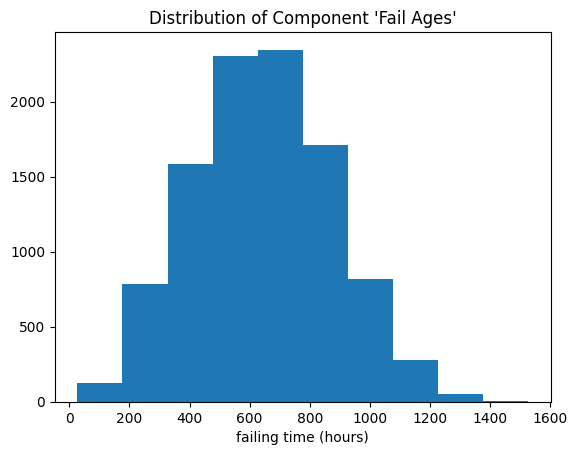

In [4]:
fail_ages = eta*np.random.weibull(beta, size=10000)

plt.hist(fail_ages)
plt.xlabel("failing time (hours)")
plt.title("Distribution of Component 'Fail Ages'")
plt.show()

### Inspection Parameters

In [5]:
mu = 7*24
sigma = 0.15*mu

In [6]:
inspection_threshold = 0.5
inspection_deviation = 0.05 # beta: var = param * mu*(1-mu)

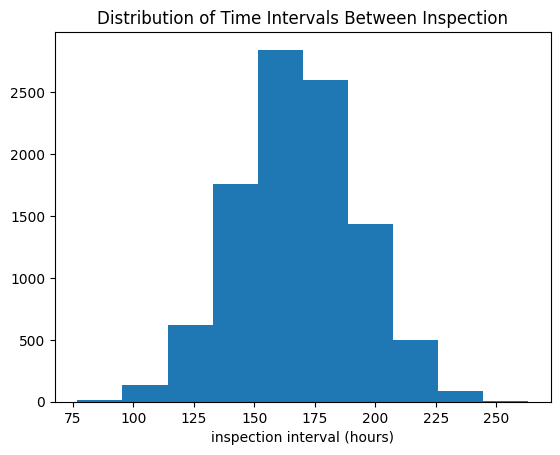

In [7]:
inspection_windows = np.random.normal(loc=mu, scale=sigma, size=10000)

plt.hist(inspection_windows)
plt.xlabel("inspection interval (hours)")
plt.title("Distribution of Time Intervals Between Inspection")
plt.show()

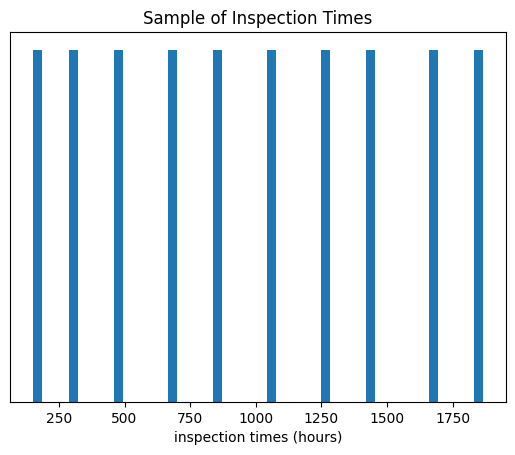

In [8]:
inspection_times = np.cumsum(inspection_windows)[:10]

plt.hist(inspection_times, bins=50)
plt.xlabel("inspection times (hours)")
plt.yticks([])
plt.title("Sample of Inspection Times")
plt.show()

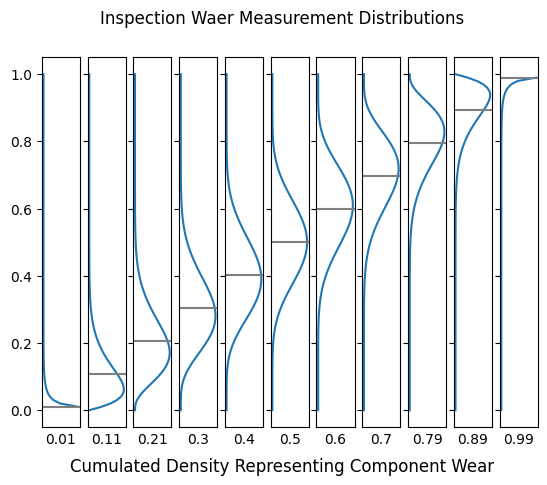

In [9]:
n = 11
fig, ax = plt.subplots(1, n, sharey=True)

cdfs = np.linspace(0.01,0.99,n)

sample = np.linspace(0,1,100)
for i in range(n):
    age_cdf = cdfs[i]

    var = inspection_deviation*age_cdf*(1-age_cdf)
    a = age_cdf * (age_cdf*(1-age_cdf)/var-1)
    b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
    
    pdf = scp.stats.beta.pdf(sample, a, b)

    ax[i].plot(pdf, sample)
    ax[i].axhline(y=age_cdf, color="gray")
    ax[i].set_xlabel(age_cdf.round(2))
    ax[i].set_xticks([])

plt.suptitle("Inspection Waer Measurement Distributions")
fig.supxlabel("Cumulated Density Representing Component Wear")
plt.show()

## Build Simulator

We build the classes and functions responsible for describing the relevant objects (Component, System) and other relevant events, such as inspections and component replacement.

In [10]:
class Component:
    def __init__(self, id_component, eta, beta):
        self.id = id_component
        
        # distribution parameters
        self.eta = eta
        self.beta = beta

        # initial age and fail age
        self.age = 0
        self.age_fail = eta*np.random.weibull(beta)

In [11]:
class Inspector:
    def __init__(self, deviation, threshold):
        self.deviation = deviation
        self.threshold = threshold
    
    def component_cdf(self, component):
        age = component.age
        eta = component.eta
        beta = component.beta

        age_cdf = scp.stats.weibull_min.cdf(age/eta, beta)

        return age_cdf
    
    def inspect(self, component):
        # exact cdf
        age_cdf = self.component_cdf(component)

        # adds imprecision by sampling from a Beta
        var = self.deviation*age_cdf*(1-age_cdf)
        a = age_cdf*(age_cdf*(1-age_cdf)/var-1)
        b = (1-age_cdf)*(age_cdf*(1-age_cdf)/var-1)
        age_beta = np.random.beta(a,b)

        # conditional report
        replace = age_beta > self.threshold

        return replace
    
    def inspect_ff(self, component):
        # exact cdf
        age_cdf = self.component_cdf(component)
        replace = age_cdf > self.threshold

        return replace
    
    def schedule_next(self, time_last_inspection, mu, sigma):
        time_next_inspection = time_last_inspection
        time_next_inspection += np.random.normal(mu, sigma)

        return time_next_inspection

In [16]:
class System:
    def __init__(self, id_system, component):
        self.id = id_system
        
        # age and component
        self.age = 0
        self.component = component
        
        # cummulated costs
        self.cost_cumulated = 0

    def next_event(self, time_last_event, next_inspection, inspector):
        # compute relevant event times
        time_to_fail = self.component.age_fail-self.component.age
        time_to_inspection = next_inspection-time_last_event
        time_to_event = min(time_to_inspection, time_to_fail)

        # update system and component age
        self.age += time_to_event
        self.component.age += time_to_event

        if time_to_event < 0:
            print(time_to_event)

        # evaluate different event cases
        ff = None
        if time_to_inspection > time_to_fail:
            event_type = "failure"
            event_cost = cost_failure
            replace_component = True
        else:
            replace = inspector.inspect(self.component)

            if replace:
                event_type = "replacement"
                event_cost = cost_replacement
                replace_component = True

                # deep inspection
                ff = inspector.inspect_ff(self.component)
            else:
                event_type = "inspection"
                event_cost = cost_inspection
                replace_component = False

        # update cost
        self.cost_cumulated += event_cost

        return time_to_event, event_type, event_cost, replace_component, ff

### System and Component Factory

Functionalities responsible for centralizing the creation of new objects with unique IDs

In [17]:
def component_factory(id_0, eta, beta):
    id_component = id_0
    while True:
        id_component += 1
        yield Component(id_component, eta, beta)

def system_factory(id_0, component_factory):
    id_system = id_0
    while True:
        id_system += 1
        component = next(component_factory)
        yield System(id_system, component)

In [18]:
def sample_system_dataset(system_factory, component_factory, inspector, n_steps = 1000,
                          time_last_event=0, time_last_inspection=0, time_origin=0):
    system_data = []

    # initialize system
    system = next(system_factory)
    for _ in range(n_steps):
        # schedule next inspection time
        if time_last_event == time_last_inspection:
            # schedule next inspection if last event was an inspection
            time_next_inspection = inspector.schedule_next(time_last_inspection, mu, sigma)

        # evaluate next relevant event
        event = system.next_event(time_last_event, time_next_inspection, inspector)
        time_interval, event_type, event_cost, replace_component, ff = event

        # update time
        time_last_event += time_interval
        if not event_type == "failure":
            time_last_inspection = time_last_event

        # update system data
        system_data.append({'system_id':system.id, 'component_id':system.component.id,
            'event_date':time_last_event, 'event_time':None, 'event_type':event_type,
            'system_age':system.age, 'component_age':system.component.age,
            'usage_since_last_event_h':time_interval, 'FF':ff, 'cost_event':event_cost,
            'cost_cumulated':system.cost_cumulated})
        
        # update system if necessary
        if replace_component:
            system.component = next(component_factory)

    system_df = pd.DataFrame(system_data)
    
    # format dates and times
    system_df.event_date = pd.to_datetime((
        system_df.event_date*60*60).astype(int), unit='s', origin=time_origin)
    system_df.event_time = system_df.event_date.dt.time
    system_df.event_date = system_df.event_date.dt.date
    system_df.system_age = system_df.system_age.astype(int)
    system_df.component_age = system_df.component_age.astype(int)
    system_df.usage_since_last_event_h = system_df.usage_since_last_event_h.astype(int)

    return system_df

### Simulate

In [19]:
c_factory = component_factory(id_0=0, eta=eta, beta=beta)
s_factory = system_factory(id_0=0, component_factory=c_factory)
inspector = Inspector(deviation=inspection_deviation, threshold=inspection_threshold)

In [39]:
df = sample_system_dataset(s_factory, c_factory, inspector, 1000)
df

,system_id,component_id,event_date,event_time,event_type,system_age,component_age,usage_since_last_event_h,FF,cost_event,cost_cumulated
0,3,499,1970-01-07,05:53:45,inspection,149,149,149,None,100,100
1,3,499,1970-01-13,22:48:35,inspection,310,310,160,None,100,200
2,3,499,1970-01-18,14:48:28,failure,422,422,111,None,1200,1400
3,3,500,1970-01-20,18:03:02,inspection,474,51,51,None,100,1500
4,3,500,1970-01-25,21:01:16,inspection,597,174,122,None,100,1600
...,...,...,...,...,...,...,...,...,...,...,...
995,3,745,1986-03-05,11:54:07,replacement,141779,609,162,False,1000,352900
996,3,746,1986-03-15,02:02:00,inspection,142010,230,230,None,100,353000
997,3,746,1986-03-23,03:57:02,inspection,142203,424,193,None,100,353100
998,3,746,1986-03-28,15:27:54,failure,142335,555,131,None,1200,354300


### Observe the distribution of fail ages

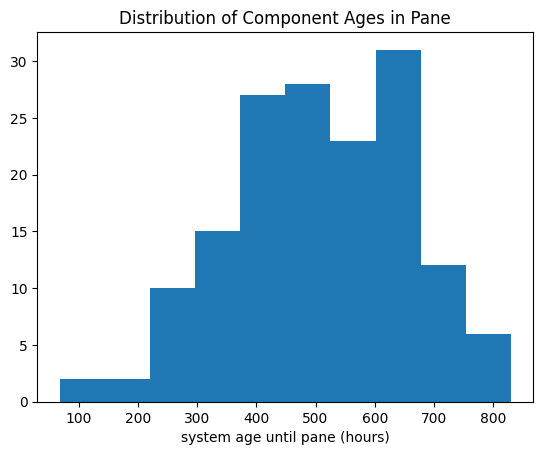

In [40]:
plt.hist(df[df.event_type=="failure"].component_age)
plt.xlabel("system age until pane (hours)")
plt.title("Distribution of Component Ages in Pane")
plt.show()

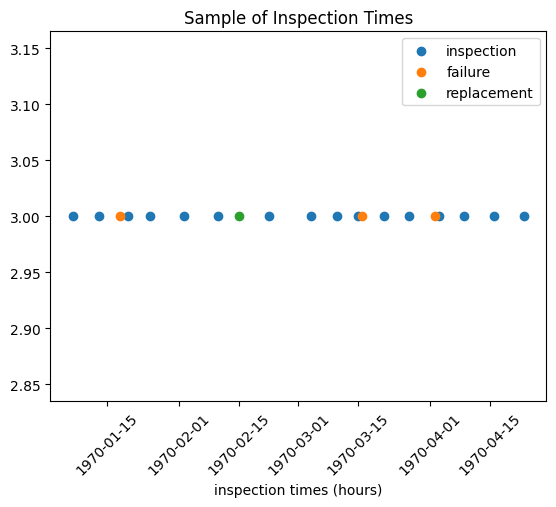

In [41]:
n_events_show = 20
for e_type in df.event_type.unique():
    df_ = df[:n_events_show]
    df_ = df_[df_.event_type == e_type]
    plt.scatter(df_.event_date,
                df_.system_id,
                label=e_type)

plt.legend()
plt.xlabel("inspection times (hours)")
plt.xticks(rotation=45)
plt.title("Sample of Inspection Times")
plt.show()

### Generate CSV Files

In [ ]:
n_systems = 4
n_steps = 1000

for i in range(n_systems):
    df = sample_system_dataset(s_factory, c_factory, inspector, 1000)
    df.to_csv(f"sample_system_dataset_{i}.csv")